In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def detect_lanes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blurred, 50, 150)
    
    height, width = edges.shape
    mask = np.zeros_like(edges)
    
    polygon = np.array([[
        (0, height),
        (width // 2 - 50, height // 2 + 50),
        (width // 2 + 50, height // 2 + 50),
        (width, height)
    ]], np.int32)
    cv2.fillPoly(mask, polygon, 255)
    
    masked_edges = cv2.bitwise_and(edges, mask)
    
    lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 100, minLineLength=50, maxLineGap=50)
    
    return lines

In [14]:
def draw_lines(images, lines):
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(images, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return images

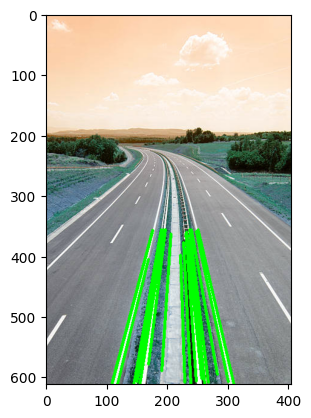

In [19]:
img = cv2.imread('images.jpg')

lines = detect_lanes(img)
result = draw_lines(img, lines)

plt.imshow(result)